<a href="https://colab.research.google.com/github/Andalejo1109/Gold-trading-bot-vs-long-term-investing/blob/main/Bot_1D_vs_B%26H_vs_Andalejo_since_2018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 11.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninsta

In [2]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np


Descargando datos del Oro (GC=F) desde 2023-08-03...
Descargando datos del Portafolio (SPYG, SMH, BRK-B, IEMG, VTI)...


/tmp/ipykernel_1531/732385204.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_oro = yf.download(TICKER_ORO, start=FECHA_INICIO, interval="1d", progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_1531/732385204.py:52: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_etfs = yf.download(tickers_etf, start=FECHA_INICIO, interval="1d", progress=False)['Close']
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is depr

-------------------------------------------------------
📊 COMPARATIVA DE RENDIMIENTO (Desde 2023-08-03)
-------------------------------------------------------
Buy & Hold Oro             : 128.75%
Bot EMA 9/21 (Oro)         : 63.08%
Mi Portafolio Estructural  : 112.35%
-------------------------------------------------------


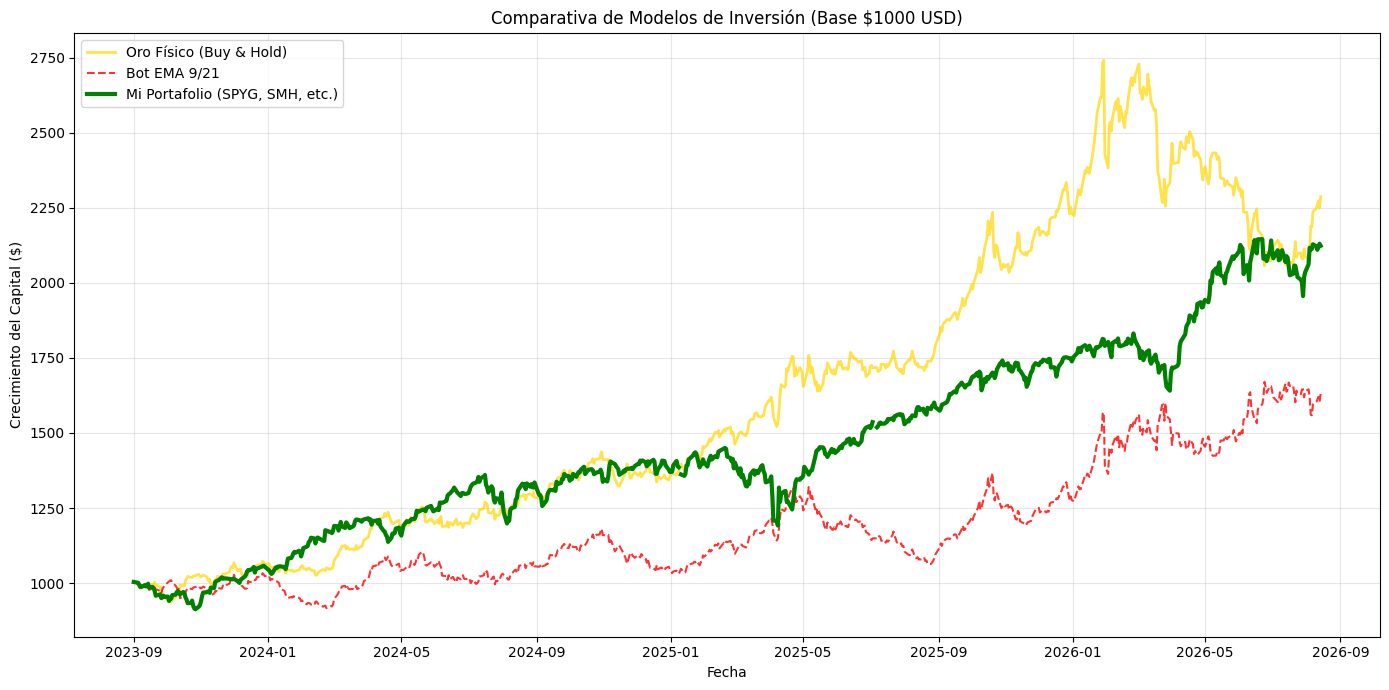

In [6]:

# ==========================================
# 1. PARÁMETROS DEL BACKTEST Y PORTAFOLIO
# ==========================================
FECHA_INICIO = "2023-08-03"
TICKER_ORO = "GC=F"  # Futuros del Oro
COSTO_TRANSACCION = 0.00015

# Tu portafolio de inversión estructural
PORTAFOLIO = {
    "SPYG": 0.35,  # S&P 500 Growth
    "SMH": 0.20,   # Semiconductores
    "BRK-B": 0.20, # Berkshire Hathaway (Sintaxis de Yahoo Finance)
    "IEMG": 0.15,  # Mercados Emergentes
    "VTI": 0.10    # Total Stock Market
}

# ==========================================
# 2. DESCARGA Y CÁLCULO DE LA ESTRATEGIA (ORO)
# ==========================================
print(f"Descargando datos del Oro ({TICKER_ORO}) desde {FECHA_INICIO}...")
df_oro = yf.download(TICKER_ORO, start=FECHA_INICIO, interval="1d", progress=False)

if isinstance(df_oro.columns, pd.MultiIndex):
    df_oro.columns = df_oro.columns.get_level_values(0)

# Indicadores y señales
df_oro.ta.ema(close='Close', length=9, append=True)
df_oro.ta.ema(close='Close', length=21, append=True)
df_oro.rename(columns={'EMA_9': 'ema_9', 'EMA_21': 'ema_21'}, inplace=True)
df_oro.dropna(inplace=True)

df_oro['signal'] = np.where(df_oro['ema_9'] > df_oro['ema_21'], 1, -1)
df_oro['position'] = df_oro['signal'].shift(1)
df_oro.dropna(inplace=True)

# Rendimientos del Oro
df_oro['returns_bh_oro'] = df_oro['Close'].pct_change()
df_oro['returns_strategy'] = df_oro['returns_bh_oro'] * df_oro['position']

df_oro['trade'] = df_oro['position'].diff().abs() > 0
df_oro.loc[df_oro['trade'], 'returns_strategy'] -= COSTO_TRANSACCION

# Capitalizamos el Oro y el Bot (Base $1000)
df_oro['equity_bh_oro'] = (1 + df_oro['returns_bh_oro']).cumprod() * 1000
df_oro['equity_strategy'] = (1 + df_oro['returns_strategy']).cumprod() * 1000

# ==========================================
# 3. DESCARGA Y CÁLCULO DE TU PORTAFOLIO ETF
# ==========================================
tickers_etf = list(PORTAFOLIO.keys())
print(f"Descargando datos del Portafolio ({', '.join(tickers_etf)})...")
df_etfs = yf.download(tickers_etf, start=FECHA_INICIO, interval="1d", progress=False)['Close']

# Calcular rendimientos diarios de cada ETF
rendimientos_etfs = df_etfs.pct_change()

# Multiplicar el rendimiento de cada ETF por su peso en el portafolio
for ticker, peso in PORTAFOLIO.items():
    rendimientos_etfs[ticker] = rendimientos_etfs[ticker] * peso

# Sumar horizontalmente para obtener el rendimiento diario total de tu portafolio
# Se asigna directamente al índice del df_oro para alinear fechas automáticamente
df_oro['returns_mi_portafolio'] = rendimientos_etfs.sum(axis=1)

# Capitalizar tu portafolio (Base $1000)
df_oro['equity_mi_portafolio'] = (1 + df_oro['returns_mi_portafolio']).cumprod() * 1000

# ==========================================
# 4. MÉTRICAS COMPARATIVAS
# ==========================================
rendimiento_bh_oro = (df_oro['equity_bh_oro'].iloc[-1] / 1000 - 1) * 100
rendimiento_estrategia = (df_oro['equity_strategy'].iloc[-1] / 1000 - 1) * 100
rendimiento_mi_portafolio = (df_oro['equity_mi_portafolio'].iloc[-1] / 1000 - 1) * 100

print("-" * 55)
print(f"📊 COMPARATIVA DE RENDIMIENTO (Desde {FECHA_INICIO})")
print("-" * 55)
print(f"Buy & Hold Oro             : {rendimiento_bh_oro:.2f}%")
print(f"Bot EMA 9/21 (Oro)         : {rendimiento_estrategia:.2f}%")
print(f"Mi Portafolio Estructural  : {rendimiento_mi_portafolio:.2f}%")
print("-" * 55)

# ==========================================
# 5. VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(14, 7))

# Gráfica 1: Buy & Hold Oro
plt.plot(df_oro.index, df_oro['equity_bh_oro'], label='Oro Físico (Buy & Hold)', color='gold', alpha=0.7, linewidth=2)

# Gráfica 2: Bot de Trading
plt.plot(df_oro.index, df_oro['equity_strategy'], label='Bot EMA 9/21', color='red', alpha=0.8, linewidth=1.5, linestyle='--')

# Gráfica 3: Tu Portafolio
plt.plot(df_oro.index, df_oro['equity_mi_portafolio'], label='Mi Portafolio (SPYG, SMH, etc.)', color='green', linewidth=3)

plt.title('Comparativa de Modelos de Inversión (Base $1000 USD)')
plt.ylabel('Crecimiento del Capital ($)')
plt.xlabel('Fecha')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Descargando datos del Oro (GC=F) desde 2018-01-01...
Descargando datos del Portafolio (SPYG, SMH, BRK-B, IEMG, VTI)...


/tmp/ipykernel_1531/1429925583.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_oro = yf.download(TICKER_ORO, start=FECHA_INICIO, interval="1d", progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_1531/1429925583.py:52: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_etfs = yf.download(tickers_etf, start=FECHA_INICIO, interval="1d", progress=False)['Close']
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is de

-------------------------------------------------------
📊 COMPARATIVA DE RENDIMIENTO (Desde 2018-01-01)
-------------------------------------------------------
Buy & Hold Oro             : 232.71%
Bot EMA 9/21 (Oro)         : 8.43%
Mi Portafolio Estructural  : 300.50%
-------------------------------------------------------


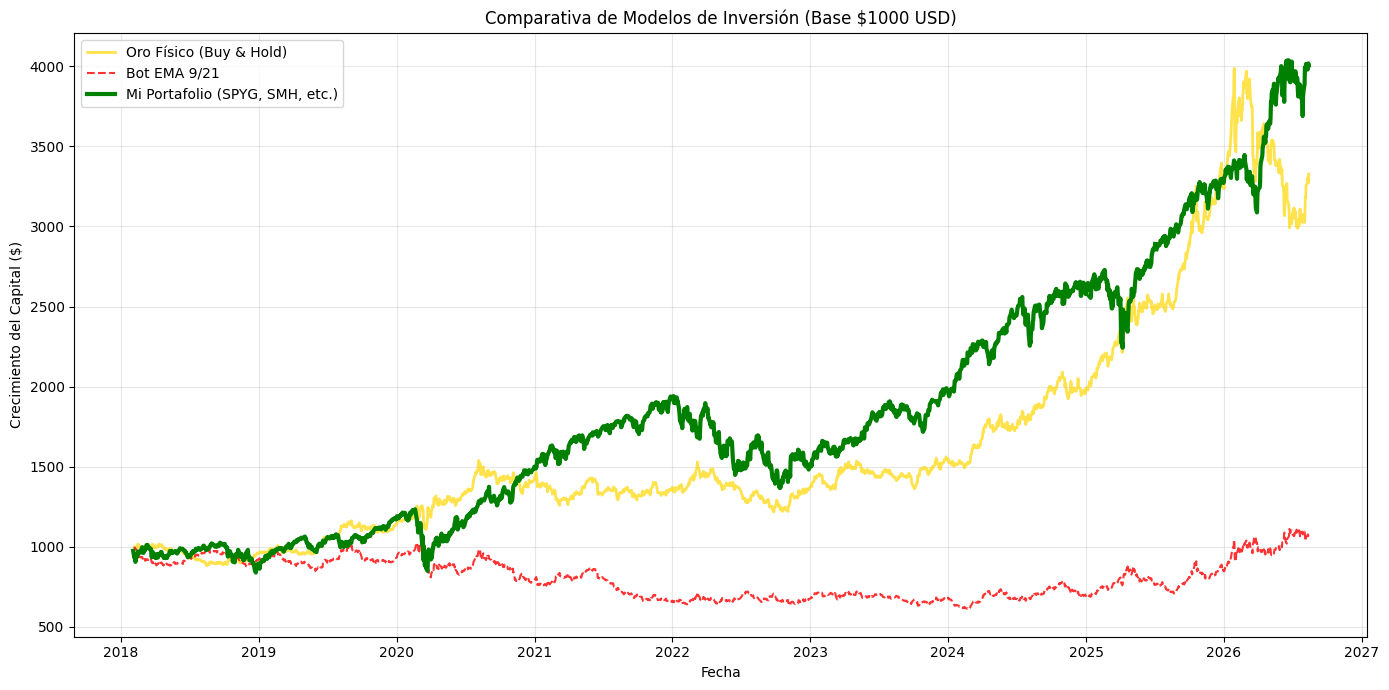

In [5]:

# ==========================================
# 1. PARÁMETROS DEL BACKTEST Y PORTAFOLIO
# ==========================================
FECHA_INICIO = "2018-01-01"
TICKER_ORO = "GC=F"  # Futuros del Oro
COSTO_TRANSACCION = 0.00015

# Tu portafolio de inversión estructural
PORTAFOLIO = {
    "SPYG": 0.35,  # S&P 500 Growth
    "SMH": 0.20,   # Semiconductores
    "BRK-B": 0.20, # Berkshire Hathaway (Sintaxis de Yahoo Finance)
    "IEMG": 0.15,  # Mercados Emergentes
    "VTI": 0.10    # Total Stock Market
}

# ==========================================
# 2. DESCARGA Y CÁLCULO DE LA ESTRATEGIA (ORO)
# ==========================================
print(f"Descargando datos del Oro ({TICKER_ORO}) desde {FECHA_INICIO}...")
df_oro = yf.download(TICKER_ORO, start=FECHA_INICIO, interval="1d", progress=False)

if isinstance(df_oro.columns, pd.MultiIndex):
    df_oro.columns = df_oro.columns.get_level_values(0)

# Indicadores y señales
df_oro.ta.ema(close='Close', length=9, append=True)
df_oro.ta.ema(close='Close', length=21, append=True)
df_oro.rename(columns={'EMA_9': 'ema_9', 'EMA_21': 'ema_21'}, inplace=True)
df_oro.dropna(inplace=True)

df_oro['signal'] = np.where(df_oro['ema_9'] > df_oro['ema_21'], 1, -1)
df_oro['position'] = df_oro['signal'].shift(1)
df_oro.dropna(inplace=True)

# Rendimientos del Oro
df_oro['returns_bh_oro'] = df_oro['Close'].pct_change()
df_oro['returns_strategy'] = df_oro['returns_bh_oro'] * df_oro['position']

df_oro['trade'] = df_oro['position'].diff().abs() > 0
df_oro.loc[df_oro['trade'], 'returns_strategy'] -= COSTO_TRANSACCION

# Capitalizamos el Oro y el Bot (Base $1000)
df_oro['equity_bh_oro'] = (1 + df_oro['returns_bh_oro']).cumprod() * 1000
df_oro['equity_strategy'] = (1 + df_oro['returns_strategy']).cumprod() * 1000

# ==========================================
# 3. DESCARGA Y CÁLCULO DE TU PORTAFOLIO ETF
# ==========================================
tickers_etf = list(PORTAFOLIO.keys())
print(f"Descargando datos del Portafolio ({', '.join(tickers_etf)})...")
df_etfs = yf.download(tickers_etf, start=FECHA_INICIO, interval="1d", progress=False)['Close']

# Calcular rendimientos diarios de cada ETF
rendimientos_etfs = df_etfs.pct_change()

# Multiplicar el rendimiento de cada ETF por su peso en el portafolio
for ticker, peso in PORTAFOLIO.items():
    rendimientos_etfs[ticker] = rendimientos_etfs[ticker] * peso

# Sumar horizontalmente para obtener el rendimiento diario total de tu portafolio
# Se asigna directamente al índice del df_oro para alinear fechas automáticamente
df_oro['returns_mi_portafolio'] = rendimientos_etfs.sum(axis=1)

# Capitalizar tu portafolio (Base $1000)
df_oro['equity_mi_portafolio'] = (1 + df_oro['returns_mi_portafolio']).cumprod() * 1000

# ==========================================
# 4. MÉTRICAS COMPARATIVAS
# ==========================================
rendimiento_bh_oro = (df_oro['equity_bh_oro'].iloc[-1] / 1000 - 1) * 100
rendimiento_estrategia = (df_oro['equity_strategy'].iloc[-1] / 1000 - 1) * 100
rendimiento_mi_portafolio = (df_oro['equity_mi_portafolio'].iloc[-1] / 1000 - 1) * 100

print("-" * 55)
print(f"📊 COMPARATIVA DE RENDIMIENTO (Desde {FECHA_INICIO})")
print("-" * 55)
print(f"Buy & Hold Oro             : {rendimiento_bh_oro:.2f}%")
print(f"Bot EMA 9/21 (Oro)         : {rendimiento_estrategia:.2f}%")
print(f"Mi Portafolio Estructural  : {rendimiento_mi_portafolio:.2f}%")
print("-" * 55)

# ==========================================
# 5. VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(14, 7))

# Gráfica 1: Buy & Hold Oro
plt.plot(df_oro.index, df_oro['equity_bh_oro'], label='Oro Físico (Buy & Hold)', color='gold', alpha=0.7, linewidth=2)

# Gráfica 2: Bot de Trading
plt.plot(df_oro.index, df_oro['equity_strategy'], label='Bot EMA 9/21', color='red', alpha=0.8, linewidth=1.5, linestyle='--')

# Gráfica 3: Tu Portafolio
plt.plot(df_oro.index, df_oro['equity_mi_portafolio'], label='Mi Portafolio (SPYG, SMH, etc.)', color='green', linewidth=3)

plt.title('Comparativa de Modelos de Inversión (Base $1000 USD)')
plt.ylabel('Crecimiento del Capital ($)')
plt.xlabel('Fecha')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()